<a href="https://colab.research.google.com/github/zaky100/Air-Quality-Analysis/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1**

In [5]:
import pandas as pd

df_changping = pd.read_csv('PRSA_Data_Changping_20130301-20170228 (1).csv')
df_dingling = pd.read_csv('PRSA_Data_Dingling_20130301-20170228 (1).csv')
df_dongsi = pd.read_csv('PRSA_Data_Dongsi_20130301-20170228 (1).csv')
df_tiantan = pd.read_csv('PRSA_Data_Tiantan_20130301-20170228 (1).csv')

df_changping['category'] = 'Outer (Suburban)'
df_dingling['category'] = 'Outer (Suburban)'
df_dongsi['category'] = 'Inner (Urban)'
df_tiantan['category'] = 'Inner (Urban)'

# Merge
df = pd.concat([df_changping, df_dingling, df_dongsi, df_tiantan], ignore_index=True)

# Handle Timestamps
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.drop(columns=['No', 'year', 'month', 'day', 'hour'], inplace=True)

cols = ['datetime', 'station', 'category'] + [col for col in df.columns if col not in ['datetime', 'station', 'category']]
df = df[cols]

# Save
df.to_csv('Task1_Combined_Data.csv', index=False)
print("Complete")

Complete


# **Task 2.1 & 2.2**

In [6]:
import pandas as pd


df = pd.read_csv('Task1_Combined_Data.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# 2.1 Data Understanding
print(f"Data Shape: {df.shape}")
print("\n--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

# 2.2 Data Preprocessing

num_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df[num_cols] = df[num_cols].interpolate(method='linear').bfill().ffill()

df['wd'] = df['wd'].ffill().bfill()

# Feature Engineering
df['Year'] = df['datetime'].dt.year
df['Month'] = df['datetime'].dt.month
df['Hour'] = df['datetime'].dt.hour
df['DayOfWeek'] = df['datetime'].dt.dayofweek

# Save cleaned data
df.to_csv('Task2_Cleaned_Data.csv', index=False)
print("\nTask 2.2 Complete")

Data Shape: (140256, 15)

--- Missing Values Before Cleaning ---
datetime       0
station        0
category       0
PM2.5       2980
PM10        2388
SO2         3139
NO2         4246
CO          7856
O3          3325
TEMP         146
PRES         140
DEWP         146
RAIN         142
wd           436
WSPM         114
dtype: int64

Task 2.2 Complete


# **Task 2.3**

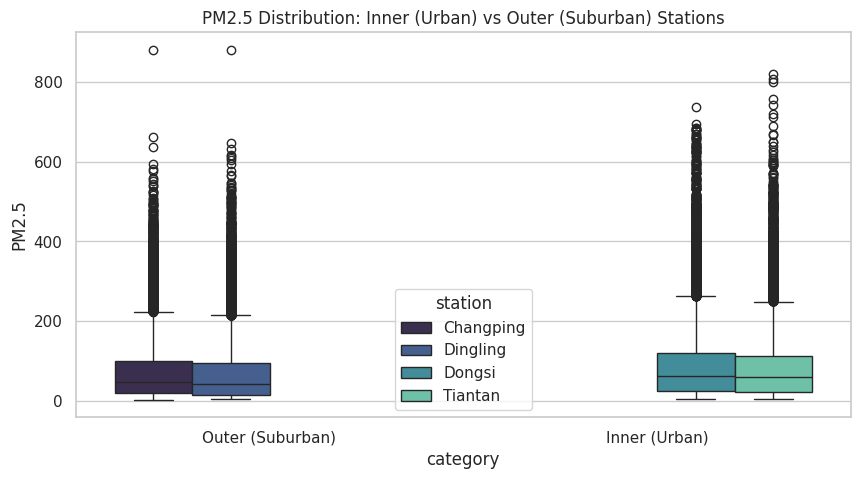

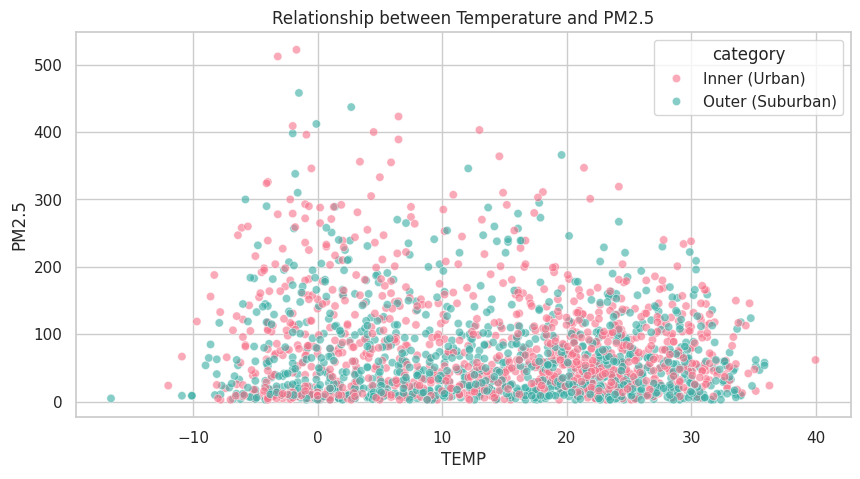

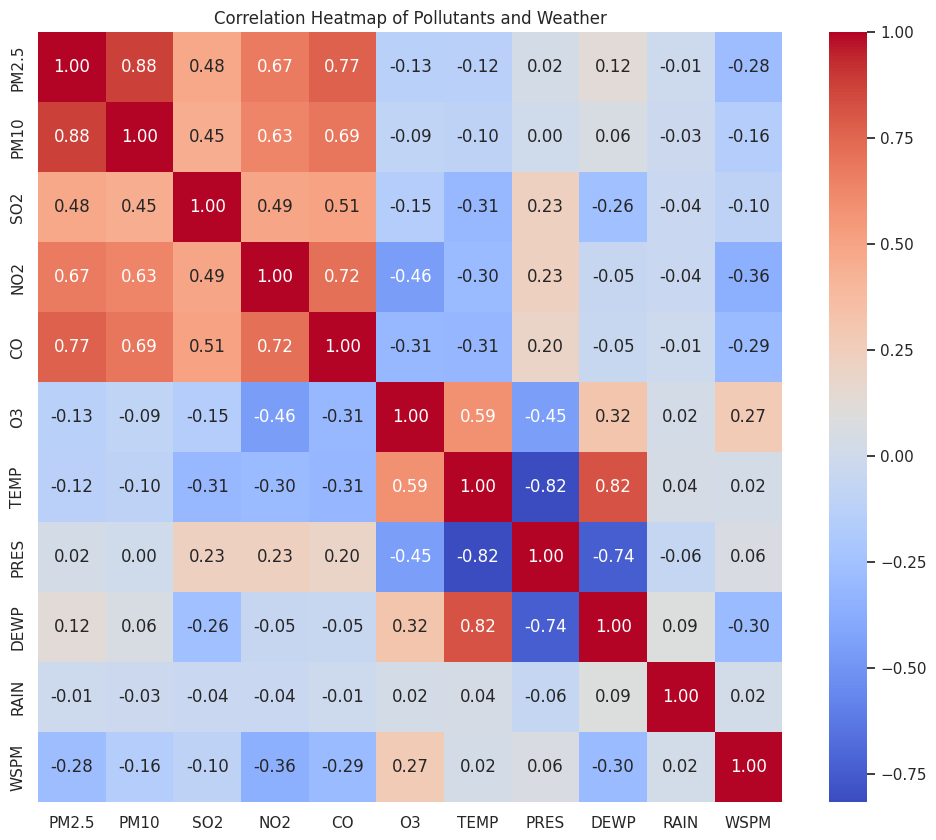

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Task2_Cleaned_Data.csv')
sns.set_theme(style="whitegrid")

# Plot 1: Comparison of Stations
plt.figure(figsize=(10, 5))
sns.boxplot(x='category', y='PM2.5', hue='station', data=df, palette='mako')
plt.title('PM2.5 Distribution: Inner (Urban) vs Outer (Suburban) Stations')
plt.show()

# Plot 2: Relationship between Temp and PM2.5
plt.figure(figsize=(10, 5))
sns.scatterplot(x='TEMP', y='PM2.5', hue='category', data=df.sample(2000, random_state=42), alpha=0.6, palette='husl')
plt.title('Relationship between Temperature and PM2.5')
plt.show()

# Plot 3: Correlation Heatmap
plt.figure(figsize=(12, 10))
num_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Pollutants and Weather')
plt.show()

# **Task 3**

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

df = pd.read_csv('Task2_Cleaned_Data.csv')

# Feature Selection
target = 'PM2.5'
numeric_features = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'Month', 'Hour']
categorical_features = ['wd', 'category']

# One-Hot Encoding
df_encoded = pd.get_dummies(df[numeric_features + categorical_features], drop_first=True)
X = df_encoded
y = df[target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training
print("Training Random Forest Model")
model = RandomForestRegressor(n_estimators=50, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# Evaluation
y_pred = model.predict(X_test_scaled)
print(f"R-squared (R2): {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Save Model
joblib.dump(model, 'rf_model.pkl', compress=3)
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns, 'model_columns.pkl')
print("Task 3 Complete")

Training Random Forest Model
R-squared (R2): 0.9349
MAE: 11.86
RMSE: 19.77
Task 3 Complete


# **Application**

In [9]:
import os

# streamlit
!pip install streamlit -q

# CSS
os.makedirs('.streamlit', exist_ok=True)
with open('.streamlit/config.toml', 'w') as f:
    f.write("""
[theme]
primaryColor = "#FF6F61"
backgroundColor = "#FDF6E3"
secondaryBackgroundColor = "#EFE8D6"
textColor = "#2D3436"
font = "sans serif"
""")

# Code
app_code = """
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np

# Setting up the page first
st.set_page_config(page_title="Air Quality Dashboard", layout="wide")

# Data caching
@st.cache_data
def load_data():
    df = pd.read_csv('Task2_Cleaned_Data.csv')
    return df

# Model caching
@st.cache_resource
def load_ml_components():
    model = joblib.load('rf_model.pkl')
    scaler = joblib.load('scaler.pkl')
    model_columns = joblib.load('model_columns.pkl')
    return model, scaler, model_columns

df = load_data()

st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to:", ["Dataset Overview", "Visualizations", "Model Outputs"])

#  DATASET OVERVIEW
if page == "Dataset Overview":
    st.title("Dataset Overview")
    st.write("This section allows you to explore the raw and cleaned air quality data from Beijing.")

    # Station Filter
    station_choice = st.selectbox("Filter by Station:", df['station'].unique())
    filtered_df = df[df['station'] == station_choice]

    st.write(f"Showing data for **{station_choice}** (First 100 rows):")
    st.dataframe(filtered_df.head(100))

    st.write("### Statistical Summary")
    st.write(filtered_df.describe())

#  VISUALIZATIONS
elif page == "Visualizations":
    st.title("Data Visualizations")
    st.write("Explore relationships between pollutants and meteorological factors.")

    pollutant = st.selectbox("Select Pollutant:", ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3'])

    st.subheader(f"{pollutant} Distribution Across Stations")
    fig, ax = plt.subplots(figsize=(10, 4))
    # Using the theme's background to make plots look seamless
    fig.patch.set_facecolor('#FDF6E3')
    ax.set_facecolor('#FFFFFF')
    sns.boxplot(x='station', y=pollutant, data=df, ax=ax, palette="mako")
    st.pyplot(fig)

    st.subheader(f"Temperature vs {pollutant}")
    sample_df = df.sample(2000, random_state=42)
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    fig2.patch.set_facecolor('#FDF6E3')
    ax2.set_facecolor('#FFFFFF')
    sns.scatterplot(x='TEMP', y=pollutant, hue='category', data=sample_df, alpha=0.6, ax=ax2, palette="husl")
    st.pyplot(fig2)

#  MODEL OUTPUTS
elif page == "Model Outputs":
    st.title("Predictive Model (PM2.5)")
    st.write("Adjust the weather and time conditions below to predict the PM2.5 pollution level.")

    try:
        # Load the cached model
        model, scaler, model_columns = load_ml_components()

        # Wrapped in a Form so the app doesn't lag when sliders are moved
        with st.form("prediction_form"):
            # Creating sliders for user input
            col1, col2, col3 = st.columns(3)
            with col1:
                temp = st.slider("Temperature (°C)", -20.0, 40.0, 10.0)
                pres = st.slider("Pressure (hPa)", 990.0, 1040.0, 1015.0)
                dewp = st.slider("Dew Point (°C)", -30.0, 30.0, 0.0)
            with col2:
                rain = st.slider("Rainfall (mm)", 0.0, 50.0, 0.0)
                wspm = st.slider("Wind Speed (m/s)", 0.0, 10.0, 2.0)
                month = st.slider("Month", 1, 12, 6)
            with col3:
                hour = st.slider("Hour of Day", 0, 23, 12)
                category = st.selectbox("Station Category", ['Inner (Urban)', 'Outer (Suburban)'])
                wd = st.selectbox("Wind Direction", ['N', 'E', 'S', 'W', 'NW', 'NE', 'SW', 'SE'])

            submit_button = st.form_submit_button("Predict PM2.5 Level")

        # Action taken only after clicking the button
        if submit_button:
            # Add static average values for other pollutants just to make a prediction
            pm10, so2, no2, co, o3 = 80.0, 15.0, 40.0, 1000.0, 50.0

            # Create a dataframe for the user input
            input_dict = {
                'PM10': pm10, 'SO2': so2, 'NO2': no2, 'CO': co, 'O3': o3,
                'TEMP': temp, 'PRES': pres, 'DEWP': dewp, 'RAIN': rain, 'WSPM': wspm,
                'Month': month, 'Hour': hour, 'wd': wd, 'category': category
            }
            input_df = pd.DataFrame([input_dict])

            # One-Hot Encode
            input_encoded = pd.get_dummies(input_df)
            input_encoded = input_encoded.reindex(columns=model_columns, fill_value=0)

            input_scaled = scaler.transform(input_encoded)
            prediction = model.predict(input_scaled)

            st.success(f"### Predicted PM2.5 Level: {prediction[0]:.2f} μg/m³")

            if prediction[0] < 35:
                st.info(" Air Quality is Good")
            elif prediction[0] < 75:
                st.warning(" Air Quality is Moderate")
            else:
                st.error(" Air Quality is Unhealthy")

    except Exception as e:
        st.error(f"Error loading model: {e}. Make sure you ran Task 3 to generate the .pkl files.")
"""
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

# 4. Run Streamlit natively in the background and pop open the window
!nohup streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false > /dev/null 2>&1 &
from google.colab import output
output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>